# TCGA lung real-data analysis

Start Jupyter from the BiHPR repository root:

    jupyter notebook examples/TCGA_lung_real_data.ipynb

Run the notebook from top to bottom. Final results are saved under `outputs/tcga_lung_real_data`.


In [1]:
# 1. Imports
import json
import time
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.metrics import accuracy_score, adjusted_rand_score, confusion_matrix, rand_score
PROJECT_DIR = next(
    (candidate for directory in [Path.cwd(), *Path.cwd().parents]
     for candidate in (directory, directory / "BiHPR-main")
     if (candidate / "BiHPR" / "__init__.py").is_file()),
    None,
)
if PROJECT_DIR is None:
    raise RuntimeError("Could not find the BiHPR-main directory from the current working directory.")
sys.path.insert(0, str(PROJECT_DIR))

from BiHPR import (
    adaptive_feature_weights,
    fit_bihpr_mcp_large,
    prepare_bihpr_workspace,
)
from examples.lung_realdata_utils import (
    LocalFusedLassoInitializer,
    active_gene_tables,
    bic_for_result,
    log_normalization,
    read_lung_coef_xlsx,
    save_split_heatmap,
)


In [2]:
# 2. Fixed analysis settings
P_DIM = 600
m = 30
phi = 0.1
lambda_row = 2500
lambda_col = 3000
lambda3 = 60

nu0 = 5
nu1 = 5
nu2 = 5
nu3 = 2
niter = 1000
tol = 1e-5
output_every = 200

init_k = 20
init_alpha = 2.0
init_lam_sparsity = 10
init_lam_fusion = 20

PROJECT_DIR = next(
    path for path in [Path.cwd(), Path.cwd().parent, Path.cwd() / "BiHPR-main"]
    if (path / "BiHPR").is_dir()
)

DATA_DIR = PROJECT_DIR / "examples" / "data" / "tcga_lung"
DATA_PATH = DATA_DIR / "LUNG_data.csv"
COEF_PATH = DATA_DIR / "lung_coef.xlsx"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "tcga_lung_real_data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Load data and select genes


In [3]:
# 3. Load data and select the p=600 genes with the largest normalized variances
coef = read_lung_coef_xlsx(COEF_PATH)
available_columns = pd.read_csv(DATA_PATH, nrows=0).columns
candidate_genes = [
    gene for gene in coef["gene"].astype(str)
    if gene in available_columns
]

data = pd.read_csv(
    DATA_PATH,
    usecols=[
        "Unnamed: 0",
        "FEV1_PERCENT_REF_PREBRONCHOLIATOR",
        "CancerType",
        *candidate_genes,
    ],
)
response = data["FEV1_PERCENT_REF_PREBRONCHOLIATOR"].to_numpy(dtype=float)
cancer_type = data["CancerType"].astype(str)
true_labels = cancer_type.map({"LUSC": 0, "LUAD": 1}).to_numpy(dtype=int)

normalized_expression = log_normalization(
    data[candidate_genes].to_numpy(dtype=float),
    scale_factor=10000,
)
variance = pd.Series(
    normalized_expression.var(axis=0),
    index=candidate_genes,
).sort_values(ascending=False)

selected_features = variance.head(P_DIM).index.tolist()

X_selected = pd.DataFrame(
    normalized_expression,
    columns=candidate_genes,
)[selected_features].to_numpy(dtype=float)

print("Samples:", len(data))
print("Selected genes:", len(selected_features))


Samples: 231
Selected genes: 600


## Initialization and BiHPR fitting


In [4]:
# 4. Compute the local fused-lasso initialization and remove nearly all-zero genes
initializer = LocalFusedLassoInitializer(
    k=init_k,
    alpha=init_alpha,
    lam_sparsity=init_lam_sparsity,
    lam_fusion=init_lam_fusion,
)
start = time.time()
beta_init = initializer.fit(X_selected, response)
print(f"Initialization finished in {time.time() - start:.1f} seconds.")

keep_mask = np.mean(np.abs(beta_init) < 1e-4, axis=0) <= 0.99
X = X_selected[:, keep_mask]
beta_for_fit = beta_init[:, keep_mask]
fit_features = np.asarray(selected_features)[keep_mask]

print("Genes used for fitting:", X.shape[1])


Initialization finished in 14.6 seconds.
Genes used for fitting: 393


In [5]:
# 5. Fit the pilot and final BiHPR models
workspace = prepare_bihpr_workspace(
    response,
    X,
    nu0=nu0,
    nu1=nu1,
    nu2=nu2,
    nu3=nu3,
    m=m,
    phi=phi,
    graph_data=beta_for_fit,
)

fit_start = time.time()
pilot = fit_bihpr_mcp_large(
    response,
    X,
    lambda_col=lambda_col,
    lambda_row=lambda_row,
    lambda3=0.0,
    feature_weights=np.ones(X.shape[1]),
    beta_init=beta_for_fit,
    workspace=workspace,
    gamma_mcp=3.0,
    nu0=nu0,
    nu1=nu1,
    nu2=nu2,
    nu3=nu3,
    niter=niter,
    tol=tol,
    cluster_tol=1e-5,
    output=output_every,
)
results = fit_bihpr_mcp_large(
    response,
    X,
    lambda_col=lambda_col,
    lambda_row=lambda_row,
    lambda3=lambda3,
    feature_weights=adaptive_feature_weights(pilot["beta"]),
    init=pilot["state"],
    workspace=workspace,
    gamma_mcp=3.0,
    nu0=nu0,
    nu1=nu1,
    nu2=nu2,
    nu3=nu3,
    niter=niter,
    tol=tol,
    cluster_tol=1e-5,
    output=output_every,
)

elapsed_seconds = time.time() - fit_start
beta_final = np.asarray(results["beta"])
print(f"Fitting finished in {elapsed_seconds:.1f} seconds.")
print("RSS:", float(results["rss"]))


iter=   1  change=1.060e-02  primal=1.807e-02  mse=0.002200
iter= 200  change=1.863e-04  primal=1.175e-03  mse=0.000590
iter= 400  change=9.474e-05  primal=1.382e-04  mse=0.000183
iter= 600  change=7.061e-05  primal=3.078e-05  mse=0.000270
iter= 800  change=5.196e-05  primal=6.145e-05  mse=0.000332
iter=1000  change=3.959e-05  primal=7.431e-06  mse=0.000368
iter=   1  change=2.752e-04  primal=4.181e-04  mse=0.000368
iter= 200  change=2.881e-05  primal=4.743e-06  mse=0.000392
iter= 400  change=2.313e-05  primal=1.908e-06  mse=0.000408
iter= 600  change=1.886e-05  primal=1.103e-06  mse=0.000418
iter= 800  change=1.561e-05  primal=1.290e-06  mse=0.000426
iter=1000  change=1.369e-05  primal=1.679e-06  mse=0.000432
Fitting finished in 751.8 seconds.
RSS: 0.09987598716893056


## Clustering and final results


In [6]:
# 6. Evaluate the k=2 and k=3 clusterings
dendrogram = linkage(beta_final, method="ward")
cluster_k2 = fcluster(dendrogram, t=2, criterion="maxclust") - 1
cluster_k3 = fcluster(dendrogram, t=3, criterion="maxclust") - 1

ri_k2 = rand_score(true_labels, cluster_k2)
ari_k2 = adjusted_rand_score(true_labels, cluster_k2)
accuracy_direct = accuracy_score(true_labels, cluster_k2)
accuracy_flipped = accuracy_score(true_labels, 1 - cluster_k2)
accuracy_k2 = max(accuracy_direct, accuracy_flipped)

ri_k3 = rand_score(true_labels, cluster_k3)
ari_k3 = adjusted_rand_score(true_labels, cluster_k3)

print(f"k=2: RI={ri_k2:.4f}, ARI={ari_k2:.4f}, accuracy={accuracy_k2:.2%}")
print(f"k=3: RI={ri_k3:.4f}, ARI={ari_k3:.4f}")


k=2: RI=0.5005, ARI=-0.0217, accuracy=53.68%
k=3: RI=0.6615, ARI=0.3275


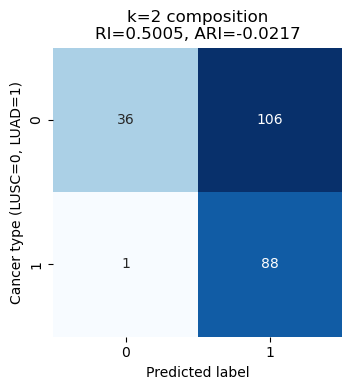

,cluster,gene,mean_beta,abs_mean_beta,is_key_gene,forced_key_gene_row
0,0,SFTPB,4.887165,4.887165,False,NaN
1,0,ABCA3,4.880084,4.880084,False,NaN
2,0,SFTPD,1.813276,1.813276,False,NaN
3,0,CEACAM6,0.332104,0.332104,False,NaN
4,0,KRT18,0.331935,0.331935,False,NaN
5,0,KRT7,0.331901,0.331901,False,NaN
6,0,CXCL17,0.331376,0.331376,False,NaN
7,0,WFDC2,0.331341,0.331341,False,NaN
8,0,MALL,0.331167,0.331167,False,NaN
9,0,CEACAM5,0.331107,0.331107,False,NaN


In [7]:
# 7. Show the k=2 composition and k=3 coefficient heatmap
predictions_for_plot = (
    1 - cluster_k2 if accuracy_flipped > accuracy_direct else cluster_k2
)
composition = confusion_matrix(true_labels, predictions_for_plot)

figure, axis = plt.subplots(figsize=(5, 4))
sns.heatmap(composition, annot=True, fmt="d", cmap="Blues", cbar=False, square=True, ax=axis)
axis.set_title(f"k=2 composition\nRI={ri_k2:.4f}, ARI={ari_k2:.4f}")
axis.set_xlabel("Predicted label")
axis.set_ylabel("Cancer type (LUSC=0, LUAD=1)")
figure.tight_layout()
plt.show()
plt.close(figure)

cluster_mean_beta, active_gene_summary = active_gene_tables(
    beta_final,
    list(fit_features),
    cluster_k3,
)
display(
    active_gene_summary.sort_values(
        ["cluster", "abs_mean_beta"],
        ascending=[True, False],
    ).groupby("cluster").head(10)
)


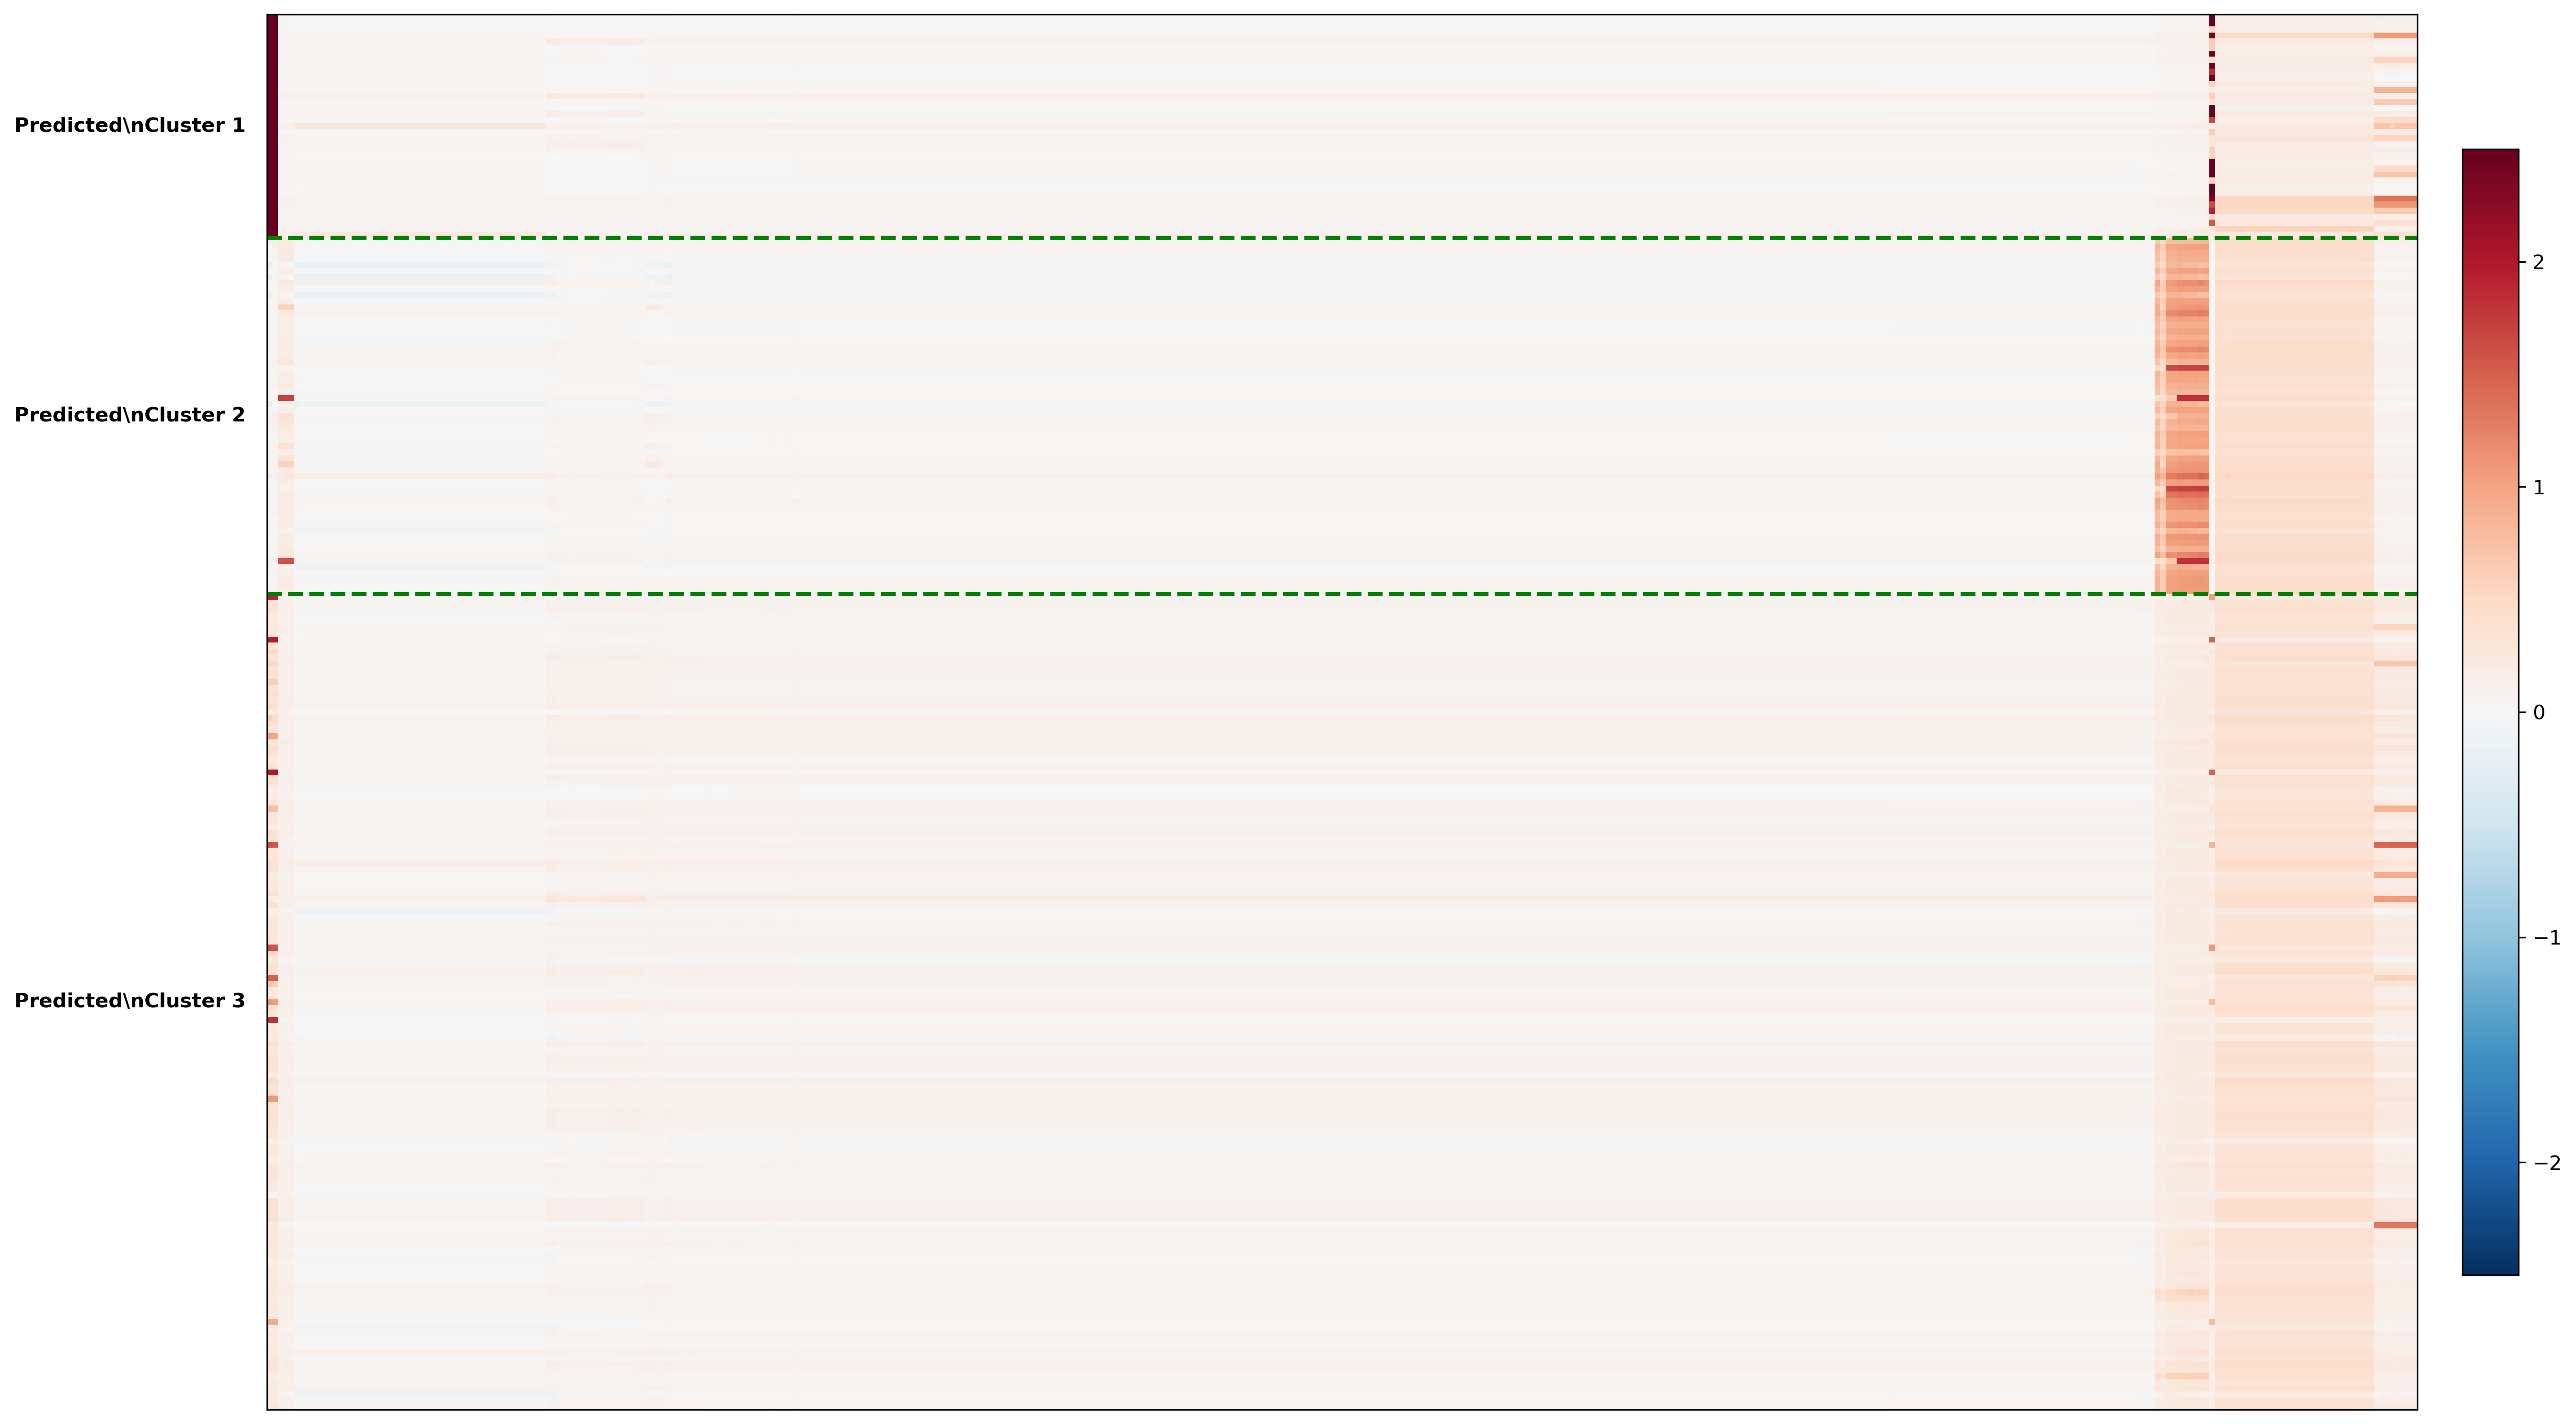

Final outputs saved to: c:\Users\33698\Desktop\Regression Bicluster v2\BiHPR-main\outputs\tcga_lung_real_data


In [8]:
# 8. Save final outputs
composition_path = OUTPUT_DIR / "cluster_composition_k2.png"
figure, axis = plt.subplots(figsize=(5, 4))
sns.heatmap(composition, annot=True, fmt="d", cmap="Blues", cbar=False, square=True, ax=axis)
axis.set_title(f"k=2 composition\nRI={ri_k2:.4f}, ARI={ari_k2:.4f}")
axis.set_xlabel("Predicted label")
axis.set_ylabel("Cancer type (LUSC=0, LUAD=1)")
figure.tight_layout()
figure.savefig(composition_path, dpi=300, bbox_inches="tight")
plt.close(figure)

heatmap_path = OUTPUT_DIR / "heatmap_k3.png"
save_split_heatmap(
    beta_final,
    list(fit_features),
    cluster_k3,
    heatmap_path,
    title="",
)

pd.DataFrame(beta_final, columns=fit_features).to_csv(
    OUTPUT_DIR / "beta_estimate.csv",
    index=False,
)
pd.DataFrame(
    {
        "sample_id": data["Unnamed: 0"].astype(str),
        "CancerType": cancer_type,
        "cluster_k2": cluster_k2,
        "cluster_k3": cluster_k3,
    }
).to_csv(OUTPUT_DIR / "clusters.csv", index=False)

summary = {
    "rss": float(results["rss"]),
    "bic": float(bic_for_result(results, X.shape[0])),
    "elapsed_seconds": float(elapsed_seconds),
    "genes_used": int(X.shape[1]),
    "k2_RI": float(ri_k2),
    "k2_ARI": float(ari_k2),
    "k2_accuracy": float(accuracy_k2),
    "k3_RI": float(ri_k3),
    "k3_ARI": float(ari_k3),
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

display(Image(filename=str(heatmap_path)))
print("Final outputs saved to:", OUTPUT_DIR)
